In [14]:
import pandas as pd
df = pd.read_csv("Distance_Matrix.csv")
df

,label,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
0,P1,0.00,1.41,6.40,7.28,6.32,9.85,2.00,8.06,4.47,4.47
1,P2,1.41,0.00,6.71,6.71,7.07,9.43,1.41,7.28,5.10,4.24
2,P3,6.40,6.71,0.00,4.24,2.24,5.10,5.39,5.66,2.24,3.00
3,P4,7.28,6.71,4.24,0.00,6.40,2.83,5.39,1.41,5.39,3.00
4,P5,6.32,7.07,2.24,6.40,0.00,7.28,6.00,7.81,2.00,4.47
5,P6,9.85,9.43,5.10,2.83,7.28,0.00,8.06,3.16,7.00,5.39
6,P7,2.00,1.41,5.39,5.39,6.00,8.06,0.00,6.08,4.00,2.83
7,P8,8.06,7.28,5.66,1.41,7.81,3.16,6.08,0.00,6.71,4.12
8,P9,4.47,5.10,2.24,5.39,2.00,7.00,4.00,6.71,0.00,2.83
9,P10,4.47,4.24,3.00,3.00,4.47,5.39,2.83,4.12,2.83,0.00


<img src="tugas_ML.png" height="250">

In [ ]:

# membersihkan data yang duplicat
import numpy as np
df_numeric = df.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
df_numeric.values[np.triu_indices_from(df_numeric, k=1)] = 0  # Mengubah segitiga atas menjadi 0

# function untuk mencari nilai terdekat
def shortest_distance(dataframe):
    min_values = []
    for i in range(0,len(dataframe.columns)):
        min_value = dataframe.replace(0, float('inf')).iloc[i].min()
        min_values.append(min_value)
    # min_values = dataframe.replace(0, float('inf')).min()
    # min_indices = dataframe[dataframe == min_values].stack().index.tolist()
    return min_values

shortest = shortest_distance(df_numeric)

 


[inf, 1.41, 6.4, 4.24, 2.24, 2.83, 1.41, 1.41, 2.0, 2.83]

In [56]:
df_numeric

,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
1,1.41,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
2,6.40,6.71,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.0
3,7.28,6.71,4.24,0.00,0.00,0.00,0.00,0.00,0.00,0.0
4,6.32,7.07,2.24,6.40,0.00,0.00,0.00,0.00,0.00,0.0
5,9.85,9.43,5.10,2.83,7.28,0.00,0.00,0.00,0.00,0.0
6,2.00,1.41,5.39,5.39,6.00,8.06,0.00,0.00,0.00,0.0
7,8.06,7.28,5.66,1.41,7.81,3.16,6.08,0.00,0.00,0.0
8,4.47,5.10,2.24,5.39,2.00,7.00,4.00,6.71,0.00,0.0
9,4.47,4.24,3.00,3.00,4.47,5.39,2.83,4.12,2.83,0.0


In [64]:
# Mengimpor pustaka yang diperlukan
import numpy as np
import pandas as pd
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

# Contoh distance matrix (10x10)
distance_matrix = np.array([
    [0, 1.41, 6.40, 7.28, 6.32, 9.85, 2.00, 8.06, 4.47, 4.47],
    [1.41, 0, 6.71, 6.71, 7.07, 9.43, 1.41, 7.28, 5.10, 4.24],
    [6.40, 6.71, 0, 4.24, 2.24, 5.10, 5.39, 5.66, 2.24, 3.00],
    [7.28, 6.71, 4.24, 0, 6.40, 2.83, 5.39, 1.41, 5.39, 3.00],
    [6.32, 7.07, 2.24, 6.40, 0, 7.28, 6.00, 7.81, 2.00, 4.47],
    [9.85, 9.43, 5.10, 2.83, 7.28, 0, 8.06, 3.16, 7.00, 5.39],
    [2.00, 1.41, 5.39, 5.39, 6.00, 8.06, 0, 6.08, 4.00, 2.83],
    [8.06, 7.28, 5.66, 1.41, 7.81, 3.16, 6.08, 0, 6.71, 4.12],
    [4.47, 5.10, 2.24, 5.39, 2.00, 7.00, 4.00, 6.71, 0, 2.83],
    [4.47, 4.24, 3.00, 3.00, 4.47, 5.39, 2.83, 4.12, 2.83, 0]
])

# Menyimpan distance matrix asli untuk iterasi
distance_matrix_iter = distance_matrix.copy()

# List untuk menyimpan hasil dataframe di setiap iterasi
dataframes_per_iteration = []

# Konversi distance matrix ke format condensed
condensed_dist_matrix = squareform(distance_matrix_iter)

# Buat linkage matrix dengan Single Linkage
linkage_matrix = sch.linkage(condensed_dist_matrix, method='single')

# Membuat DataFrame awal dari distance matrix
df_iter = pd.DataFrame(distance_matrix_iter, index=[f"P{i+1}" for i in range(len(distance_matrix))],
                       columns=[f"P{i+1}" for i in range(len(distance_matrix))])

# Simpan DataFrame awal
dataframes_per_iteration.append(df_iter.copy())

# Proses iterasi clustering
for i, row in enumerate(linkage_matrix):
    cluster_1 = int(row[0])  # Cluster pertama yang bergabung
    cluster_2 = int(row[1])  # Cluster kedua yang bergabung
    
    # Buat label untuk cluster baru
    new_label = f"C{i+1}"
    
    # Ambil label yang masih tersedia
    old_labels = df_iter.index.tolist()
    
    # Buat distance matrix baru dengan mengambil minimum (single linkage)
    new_distances = []
    new_index = []

    for label in old_labels:
        if label not in [f"P{cluster_1+1}", f"P{cluster_2+1}"]:
            dist1 = df_iter.at[label, f"P{cluster_1+1}"] if f"P{cluster_1+1}" in df_iter.columns else float('inf')
            dist2 = df_iter.at[label, f"P{cluster_2+1}"] if f"P{cluster_2+1}" in df_iter.columns else float('inf')
            new_distances.append(min(dist1, dist2))
            new_index.append(label)

    # Hapus cluster yang digabungkan dari DataFrame
    df_iter = df_iter.drop([f"P{cluster_1+1}", f"P{cluster_2+1}"], axis=0, errors='ignore')
    df_iter = df_iter.drop([f"P{cluster_1+1}", f"P{cluster_2+1}"], axis=1, errors='ignore')

    # Tambahkan cluster baru dengan nilai minimum (single linkage)
    new_index.append(new_label)
    new_distances.append(0)  # Nilai diagonal harus 0

    # Konversi ke DataFrame agar panjangnya cocok
    new_col_df = pd.DataFrame({new_label: new_distances}, index=new_index)
    df_iter = pd.concat([df_iter, new_col_df.T], axis=0)
    df_iter[new_label] = new_distances

    # Simpan DataFrame hasil iterasi ini
    dataframes_per_iteration.append(df_iter.copy())

# Menampilkan DataFrame hasil setiap iterasi
for i, df in enumerate(dataframes_per_iteration):
    print(f"\n=== Distance Matrix Setelah Iterasi {i} ===")
    print(df)


=== Distance Matrix Setelah Iterasi 0 ===
       P1    P2    P3    P4    P5    P6    P7    P8    P9   P10
P1   0.00  1.41  6.40  7.28  6.32  9.85  2.00  8.06  4.47  4.47
P2   1.41  0.00  6.71  6.71  7.07  9.43  1.41  7.28  5.10  4.24
P3   6.40  6.71  0.00  4.24  2.24  5.10  5.39  5.66  2.24  3.00
P4   7.28  6.71  4.24  0.00  6.40  2.83  5.39  1.41  5.39  3.00
P5   6.32  7.07  2.24  6.40  0.00  7.28  6.00  7.81  2.00  4.47
P6   9.85  9.43  5.10  2.83  7.28  0.00  8.06  3.16  7.00  5.39
P7   2.00  1.41  5.39  5.39  6.00  8.06  0.00  6.08  4.00  2.83
P8   8.06  7.28  5.66  1.41  7.81  3.16  6.08  0.00  6.71  4.12
P9   4.47  5.10  2.24  5.39  2.00  7.00  4.00  6.71  0.00  2.83
P10  4.47  4.24  3.00  3.00  4.47  5.39  2.83  4.12  2.83  0.00

=== Distance Matrix Setelah Iterasi 1 ===
       P3    P4    P5    P6    P7    P8    P9   P10    C1
P3   0.00  4.24  2.24  5.10  5.39  5.66  2.24  3.00  6.40
P4   4.24  0.00  6.40  2.83  5.39  1.41  5.39  3.00  6.71
P5   2.24  6.40  0.00  7.28  6.00  7

Iterasi Penggabungan Klaster (Single Linkage):
Iterasi 1: Gabung Cluster 0 dan Cluster 1 pada Jarak 1.41 (Total 2 elemen)
Iterasi 2: Gabung Cluster 3 dan Cluster 7 pada Jarak 1.41 (Total 2 elemen)
Iterasi 3: Gabung Cluster 6 dan Cluster 10 pada Jarak 1.71 (Total 3 elemen)
Iterasi 4: Gabung Cluster 4 dan Cluster 8 pada Jarak 2.00 (Total 2 elemen)
Iterasi 5: Gabung Cluster 2 dan Cluster 13 pada Jarak 2.24 (Total 3 elemen)
Iterasi 6: Gabung Cluster 5 dan Cluster 11 pada Jarak 3.00 (Total 3 elemen)
Iterasi 7: Gabung Cluster 9 dan Cluster 14 pada Jarak 3.43 (Total 4 elemen)
Iterasi 8: Gabung Cluster 12 dan Cluster 16 pada Jarak 5.25 (Total 7 elemen)
Iterasi 9: Gabung Cluster 15 dan Cluster 17 pada Jarak 6.49 (Total 10 elemen)


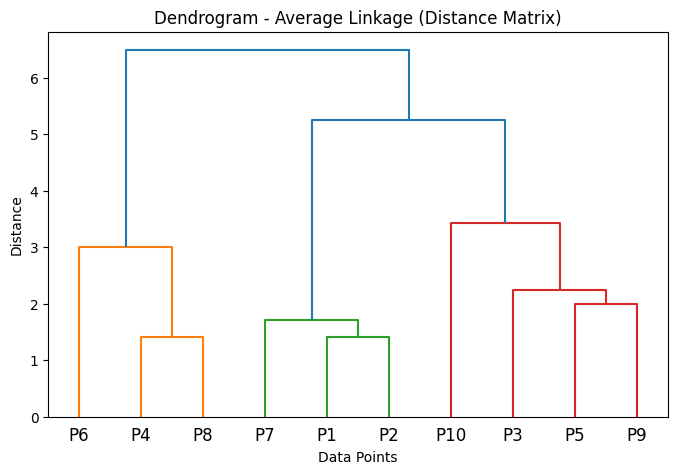

In [9]:
import numpy as np
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform

# Contoh distance matrix (10x10)
distance_matrix = np.array([
    [0, 1.41, 6.40, 7.28, 6.32, 9.85, 2.00, 8.06, 4.47, 4.47],
    [1.41, 0, 6.71, 6.71, 7.07, 9.43, 1.41, 7.28, 5.10, 4.24],
    [6.40, 6.71, 0, 4.24, 2.24, 5.10, 5.39, 5.66, 2.24, 3.00],
    [7.28, 6.71, 4.24, 0, 6.40, 2.83, 5.39, 1.41, 5.39, 3.00],
    [6.32, 7.07, 2.24, 6.40, 0, 7.28, 6.00, 7.81, 2.00, 4.47],
    [9.85, 9.43, 5.10, 2.83, 7.28, 0, 8.06, 3.16, 7.00, 5.39],
    [2.00, 1.41, 5.39, 5.39, 6.00, 8.06, 0, 6.08, 4.00, 2.83],
    [8.06, 7.28, 5.66, 1.41, 7.81, 3.16, 6.08, 0, 6.71, 4.12],
    [4.47, 5.10, 2.24, 5.39, 2.00, 7.00, 4.00, 6.71, 0, 2.83],
    [4.47, 4.24, 3.00, 3.00, 4.47, 5.39, 2.83, 4.12, 2.83, 0]
])

# Konversi distance matrix ke format condensed
condensed_dist_matrix = squareform(distance_matrix)

# Buat linkage matrix dengan Single Linkage
linkage_matrix = sch.linkage(condensed_dist_matrix, method='average')

# Menampilkan iterasi penggabungan klaster
print("Iterasi Penggabungan Klaster (Single Linkage):")
print("="*50)
for i, row in enumerate(linkage_matrix):
    cluster_1 = int(row[0])  # Cluster pertama yang bergabung
    cluster_2 = int(row[1])  # Cluster kedua yang bergabung
    distance = row[2]        # Jarak antara dua cluster
    cluster_size = int(row[3])  # Jumlah elemen dalam cluster yang baru terbentuk
    
    print(f"Iterasi {i+1}: Gabung Cluster {cluster_1} dan Cluster {cluster_2} pada Jarak {distance:.2f} (Total {cluster_size} elemen)")

# Menampilkan dendrogram
plt.figure(figsize=(8, 5))
plt.title("Dendrogram - Average Linkage (Distance Matrix)")
sch.dendrogram(linkage_matrix, labels=[f"P{i+1}" for i in range(len(distance_matrix))])
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()